# PrO and Wasserstein Gradient Flow for Lotka–Volterra Dynamics

This notebook investigates Kernel Gradient Discrepancy (KGD) as a convergence diagnostic and stopping criterion for Wasserstein Gradient Flow (WGF) in Predictive Optimisation (PrO) applied to a Lotka–Volterra predator–prey benchmark.

KGD measures the pairwise alignment of the residual WGF vector field across particles, with nearby particles contributing more strongly (usually) through the kernel weighting.

The Wasserstein gradient of the entropy-regularised objective $J(Q) = \lambda_n \frac{1}{n} \sum_{i=1}^{n} S(P_Q, x_i) + D_{\text{KL}}(Q \parallel Q_0)$ defines the velocity field:

$$\nabla_{\vartheta} \mathcal{J}(Q)(\vartheta) = \underbrace{\frac{\lambda_n}{n} \sum_{i=1}^{n} \nabla_\vartheta \left( \frac{\delta S(P_Q, x_i)}{\delta q(\vartheta)} \right)}_{\text{Predictive Data-fit Gradient}} + \underbrace{ \nabla_\vartheta\log q(\vartheta) - \nabla_\vartheta\log\pi(\vartheta) }_{\text{KL Divergence Gradient}}$$

If the swarm has reached the optimal equilibrium, this gradient should be zero everywhere. However, because we are using discrete particles, the continuous density $q$ is unknown, making the entropy term $\nabla_\vartheta \log q(\vartheta)$ impossible to compute directly.

Because we cannot compute the true gradient directly, we measure it indirectly. We introduce an arbitrary smooth "test" vector field $f(\vartheta)$ from a Reproducing Kernel Hilbert Space (RKHS) and measure how strongly our true gradient aligns with it. By taking the expected alignment over our distribution $Q$, we can rely on Stein’s Identity. Assuming the density $q$ vanishes at the boundaries of the domain, we can use integration by parts to shift the spatial derivative off of the intractable density and onto our chosen test field $f$:

Let $\frac{\lambda_n}{n} \sum_{i=1}^{n} \nabla_\vartheta \left( \frac{\delta S(P_Q, x_i)}{\delta q(\vartheta)} \right) =\nabla_{\vartheta} \mathcal{L}(Q)(\vartheta)$.

$$\int \nabla_{\vartheta} \mathcal{J}(Q)(\vartheta) \cdot f(\vartheta) \, dQ(\vartheta)$$
$$= \int \left[ \nabla_{\vartheta} \mathcal{L}(Q)(\vartheta) - (\nabla \log \pi)(\vartheta)  \right]\cdot f(\vartheta) dQ(\vartheta) + \int \left( \nabla \log q \right)(\vartheta) \cdot f(\vartheta) \, dQ(\vartheta)$$
$$= \int \left[ \nabla_{\vartheta} \mathcal{L}(Q)(\vartheta) - (\nabla \log \pi)(\vartheta) \right]\cdot f(\vartheta) dQ(\vartheta) - \int (\nabla \cdot f)(\vartheta) dQ(\vartheta)$$
$$= - \int \mathcal{T}_{Q} f(\vartheta) \, dQ(\vartheta).$$

By grouping this resulting negative divergence term with the deterministic drift terms from the loss and prior, we arrive exactly at the definition of the negative Variational Stein Operator, $-T_Q f(\vartheta)$. This mathematical maneuver is the entire reason Kernel Gradient Discrepancy is computable without knowing the continuous density of the particle swarm.

This transformation is formalized by the Variational Stein Operator ($\mathcal{T}_Q$). For an arbitrary RKHS vector field $f(\vartheta)$:

$$\mathcal{T}_{Q, \vartheta} f(\vartheta) = \nabla_\vartheta \cdot f(\vartheta) - f(\vartheta)^T b(\vartheta, Q)$$

Notice that the operator evaluates the vector field entirely using the known drift $b(\vartheta, Q) = \frac{\lambda_n}{n} \sum_{i=1}^{n} \nabla_\vartheta \left( \frac{\delta S(P_Q, x_i)}{\delta q(\vartheta)} \right) - \nabla_\vartheta\log\pi(\vartheta)$ and the spatial divergence $\nabla_\vartheta \cdot f(\vartheta)$, completely eliminating $\log q$ from the computation.

KGD is formally defined by finding the "worst-case" test field $f$ in the RKHS unit ball that maximizes this computable alignment (a Stein discrepancy):

$$\mathrm{KGD}_{\mathcal K}(Q) = \sup_{\substack{f\in\mathcal B_{\mathcal K}\\\mathcal T_Q f\in L^1(Q)}}\left\vert{}\int \mathcal T_Q f(\vartheta)\,dQ(\vartheta)\right\vert{}.$$

By the Riesz representation theorem, this operator has a unique representer in the RKHS, which we will call $v_Q$ (the projected Wasserstein gradient). The supremum is maximized when the test field $f$ points in the exact direction of $v_Q$. Therefore, the supremum is perfectly solved and reduces KGD to the norm of this projected vector field:

$$\mathrm{KGD}(Q)=\vert{}\vert{}v_Q\vert{}\vert{}_{\mathcal H_K}.$$

We can express this squared norm as a double expectation over the distribution $Q$:

$$\mathrm{KGD}^2(Q)=\iint v_Q(\vartheta)^TK(\vartheta,\vartheta')v_Q(\vartheta')\,dQ(\vartheta)dQ(\vartheta').$$


To compute this without explicitly constructing $v_Q$, we apply the Variational Stein operator to our kernel twice which creates the Stein Kernel, $h_Q(\vartheta, \vartheta')$:
$$h_Q(\vartheta, \vartheta') = \mathcal{T}_{Q, \vartheta} \mathcal{T}_{Q, \vartheta'} K(\vartheta, \vartheta')$$

Applying these operators to our kernel results in:

$$h_Q(\vartheta, \vartheta') = b_Q(\vartheta)^T K(\vartheta, \vartheta') b_Q(\vartheta') - b_Q(\vartheta)^T \nabla_{\vartheta'} K(\vartheta, \vartheta') - \nabla_\vartheta K(\vartheta, \vartheta')^T b_Q(\vartheta') + \mathrm{Tr}\big( \nabla_\vartheta \nabla_{\vartheta'} K(\vartheta, \vartheta') \big)$$

Transitioning from the continuous distribution $Q$ to our empirical particle swarm $Q_n$, the double expectation integral becomes a double summation over all $N_p$ pairwise particle interactions. This yields the exact, fully computable equation utilized in our implementation:

$$\mathrm{KGD}^2(Q_n) = \frac{1}{N_p^2} \sum_{j=1}^{N_p} \sum_{l=1}^{N_p} h_{Q_n}(\vartheta^{(j)}, \vartheta^{(l)})$$


In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pymc as pm
import pytensor
import pytensor.tensor as pt
from scipy.integrate import solve_ivp
from scipy.special import expit, logit, logsumexp


import diffrax
import jax
import jax.numpy as jnp

import pymc_prop as pro
from pymc_prop.scoring import ScoringRule
from pymc_prop.diagnostics import compute_kgd, get_bandwidth, imq_kernel

pytensor.config.linker = "cvm"
az.style.use("arviz-variat")


## Simulate predator–prey data

We infer the dynamical parameters $\theta_1 = \operatorname{logit}(\alpha)$ and $\theta_2 = \operatorname{logit}(\beta / \alpha)$. The remaining ecological parameters ($\gamma = 0.4$, $\delta = 0.02$) and initial populations ($y_0 = [10, 15]$) are fixed. The reference prior is $Q_0 = \mathcal{N}(\mu_0, \Sigma_0)$ with independent marginals $\theta_1 \sim \mathcal{N}(-0.5, 0.5^2)$ and $\theta_2 \sim \mathcal{N}(-1.0, 0.5^2)$, regularizing the particles into biologically plausible non-extinction dynamics while remaining distinctly offset from the true parameter values ($\theta^* \approx [-1.0, -1.54]$).

We evaluate two distinct observation scenarios over $T = 60$ time steps:
1. **Well-specified:** Data are generated by the classical conservative Lotka–Volterra ODE with parameter $\theta^* = (-1.0, \operatorname{logit}(\beta^*/\alpha^*))$ plus Gaussian observation noise ($\sigma = 1.0$).
2. **Misspecified (ecological carrying capacity):** The true system exhibits density-dependent intraspecific prey competition with finite carrying capacity $K = 50$:
   $$\frac{dy_1}{dt} = \alpha y_1 \left(1 - \frac{y_1}{K}\right) - \beta y_1 y_2, \qquad \frac{dy_2}{dt} = \delta y_1 y_2 - \gamma y_2$$
   The practitioner fits the classical Lotka–Volterra model ($K \to \infty$). Whereas the true dynamics display damped oscillations spiraling toward a stable focus, the fitted classical family can only produce constant-amplitude periodic orbits.


In [2]:
TRUE_ALPHA, TRUE_BETA = expit([-1.0, -3.0])
TRUE_THETA = np.array([-1.0, logit(TRUE_BETA / TRUE_ALPHA)])
GAMMA, DELTA = 0.4, 0.02
INITIAL_STATE = np.array([10.0, 15.0])
OBSERVATION_SIGMA = 1.0
OBSERVATION_TIMES = np.arange(1.0, 61.0)
PREDICTION_TIMES = np.linspace(0.0, 80.0, 500)

SEEDS = {
    "process": 30, "measurement_well": 1201, "measurement_misspecified": 1202,
    "pro_well": 1301, "pro_misspecified": 1302,
    "predictive_bayes": 1401, "predictive_pro": 1402,
}

def lv_drift(state, theta):
    alpha = expit(theta[0])
    beta = alpha * expit(theta[1])
    prey, predator = state
    return np.array([
        alpha * prey - beta * prey * predator,
        DELTA * prey * predator - GAMMA * predator,
    ])


In [3]:
# Well-specified truth: deterministic classical Lotka–Volterra ODE
well_solution = solve_ivp(
    lambda t, state: lv_drift(state, TRUE_THETA),
    (0, PREDICTION_TIMES[-1]), INITIAL_STATE, t_eval=PREDICTION_TIMES,
)
latent_well = well_solution.y.T

# Misspecified truth: prey carrying capacity (intraspecific competition, K = 50)
CARRYING_CAPACITY = 50.0

def lv_misspecified_drift(state, theta):
    alpha = expit(theta[0])
    beta = alpha * expit(theta[1])
    prey, predator = state
    return np.array([
        alpha * prey * (1.0 - prey / CARRYING_CAPACITY) - beta * prey * predator,
        DELTA * prey * predator - GAMMA * predator,
    ])

misspecified_solution = solve_ivp(
    lambda t, state: lv_misspecified_drift(state, TRUE_THETA),
    (0, PREDICTION_TIMES[-1]), INITIAL_STATE, t_eval=PREDICTION_TIMES,
)
latent_misspecified = misspecified_solution.y.T


In [4]:
latent = {
    "well-specified": latent_well,
    "misspecified": latent_misspecified,
}
latent_times = {
    "well-specified": PREDICTION_TIMES,
    "misspecified": PREDICTION_TIMES,
}

observed = {}
for name, seed in [("well-specified", SEEDS["measurement_well"]),
                   ("misspecified", SEEDS["measurement_misspecified"])]:
    values = np.column_stack([
        np.interp(OBSERVATION_TIMES, latent_times[name], latent[name][:, species])
        for species in range(2)
    ])
    measurement_rng = np.random.default_rng(seed)
    measurements = values + measurement_rng.normal(0, OBSERVATION_SIGMA, values.shape)
    rejected = measurements <= 0
    while np.any(rejected):
        measurements[rejected] = values[rejected] + measurement_rng.normal(
            0, OBSERVATION_SIGMA, np.count_nonzero(rejected)
        )
        rejected = measurements <= 0
    observed[name] = measurements


/tmp/ipykernel_68163/3231998045.py:9: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


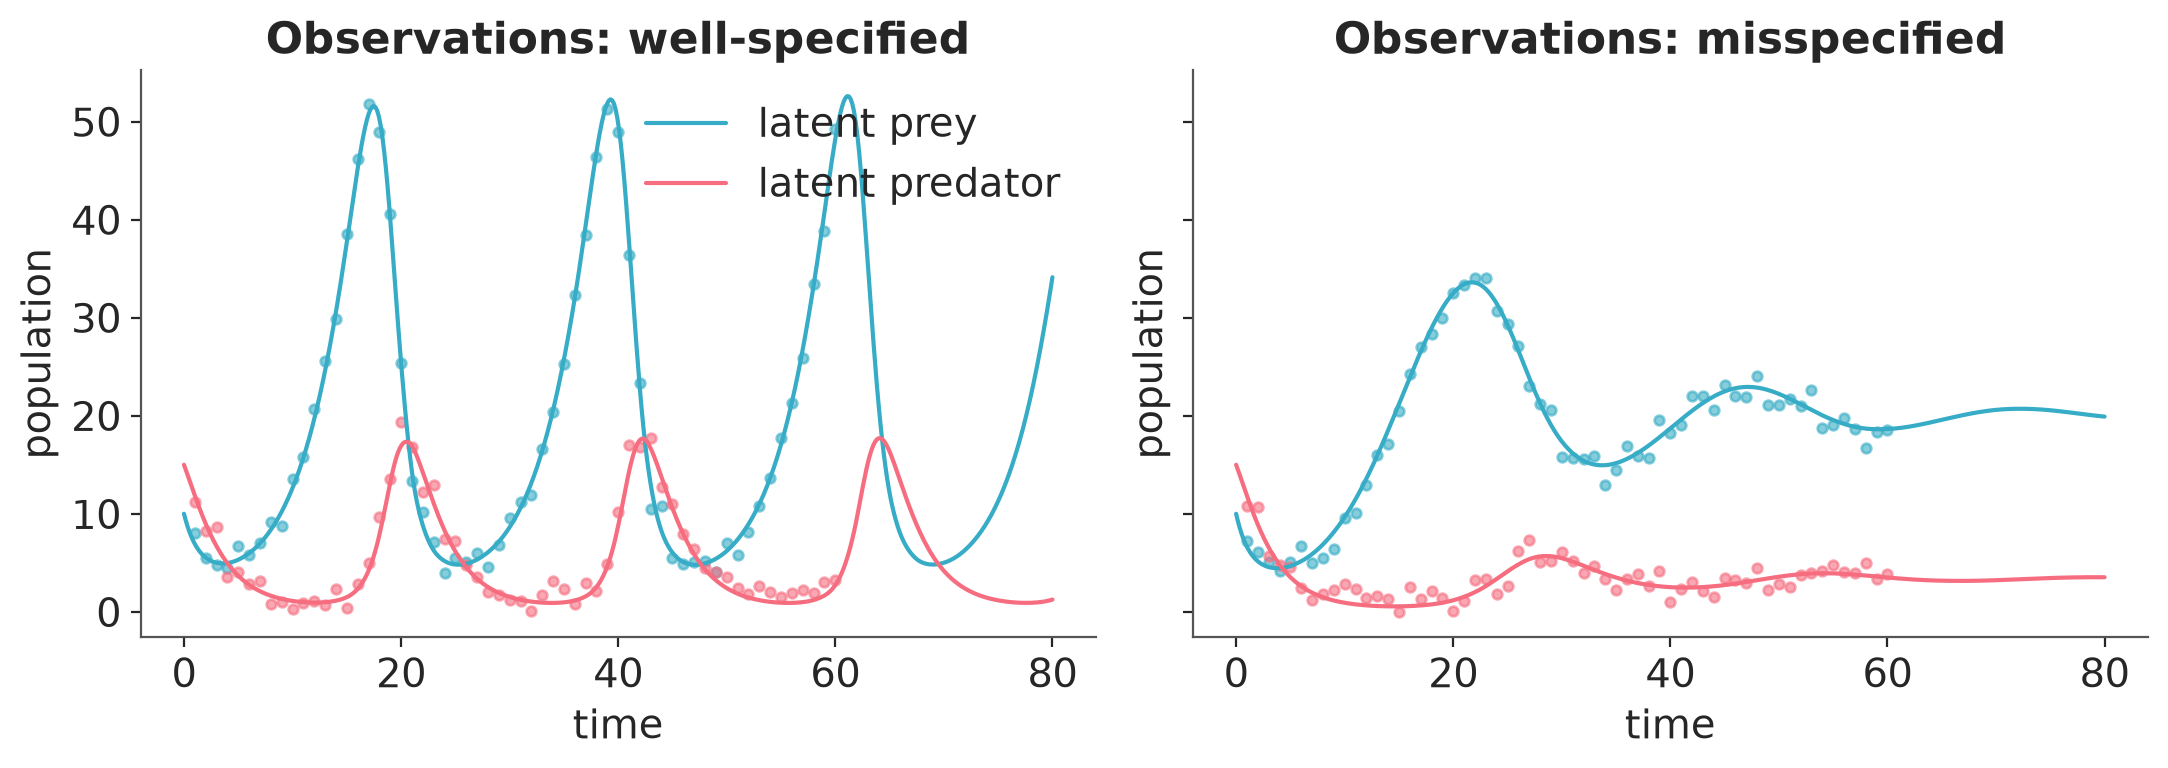

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, observed):
    ax.plot(latent_times[name], latent[name][:, 0], label="latent prey", color="C0")
    ax.plot(latent_times[name], latent[name][:, 1], label="latent predator", color="C1")
    ax.scatter(OBSERVATION_TIMES, observed[name][:, 0], s=12, alpha=0.6, color="C0")
    ax.scatter(OBSERVATION_TIMES, observed[name][:, 1], s=12, alpha=0.6, color="C1")
    ax.set(title=f"Observations: {name}", xlabel="time", ylabel="population")
axes[0].legend()
fig.tight_layout()


## PyMC model and forward-sensitivity scoring rule

We define the deterministic ODE model in PyMC. For efficient and stable WGF evaluation, we implement `LVForwardSensitivityLogScore`:
1. Batches the ODE forward sensitivity equations via JAX and Diffrax.
2. Uses symmetric log-ratio clipping (`[-8.0, 8.0]`) to ensure all particles receive informative gradient signals without exploding ratios.
3. Implements per-particle drift norm clipping (`max_norm = 250.0`), taming numerical stiffness in non-linear oscillatory parameter regimes and ensuring robust convergence.


In [6]:
def simulate_deterministic(theta, times):
    theta = np.atleast_2d(theta)
    alpha = expit(theta[:, 0])
    beta = alpha * expit(theta[:, 1])

    def rhs(t, flat_state):
        state = flat_state.reshape(len(theta), 2)
        prey, predator = state.T
        return np.column_stack([
            alpha * prey - beta * prey * predator,
            DELTA * prey * predator - GAMMA * predator,
        ]).ravel()

    solution = solve_ivp(
        rhs, (0, times[-1]), np.tile(INITIAL_STATE, len(theta)),
        t_eval=times, rtol=2e-6, atol=2e-8,
    )
    if not solution.success or not np.isfinite(solution.y).all():
        raise RuntimeError("Deterministic ODE solve failed")
    return solution.y.T.reshape(len(times), len(theta), 2).transpose(1, 0, 2)

def pymc_lv_rhs(state, time, theta):
    alpha = pt.sigmoid(theta[0])
    beta = alpha * pt.sigmoid(theta[1])
    prey, predator = state
    return [
        alpha * prey - beta * prey * predator,
        DELTA * prey * predator - GAMMA * predator,
    ]

lv_ode = pm.ode.DifferentialEquation(
    pymc_lv_rhs, times=OBSERVATION_TIMES, n_states=2, n_theta=2, t0=0
)

def build_model(data):
    with pm.Model() as model:
        theta1 = pm.Normal("theta1", -0.5, 0.5)
        theta2 = pm.Normal("theta2", -1, 0.5)
        path = lv_ode(y0=INITIAL_STATE, theta=pt.stack((theta1, theta2)))
        pm.Normal("y", path, OBSERVATION_SIGMA, observed=data)
    return model

models = {name: build_model(data) for name, data in observed.items()}


In [7]:
class LVForwardSensitivityLogScore(ScoringRule):
    """Stabilized full-mixture LV drift with batched forward sensitivities."""

    def __init__(self, data, max_norm=250.0, log_ratio_clip=8.0):
        self.data = np.asarray(data, dtype=float)
        self.max_norm = max_norm
        self.log_ratio_clip = log_ratio_clip
        self._solve = self._compile_solver()

    def _compile_solver(self):
        observation_times = jnp.asarray(OBSERVATION_TIMES)
        initial_state = jnp.asarray(INITIAL_STATE)

        def solve_particle(theta):
            alpha = jax.nn.sigmoid(theta[0])
            beta_ratio = jax.nn.sigmoid(theta[1])
            beta = alpha * beta_ratio

            def augmented_rhs(_, augmented, __):
                prey, predator = augmented[:2]
                sensitivity = augmented[2:].reshape(2, 2)
                drift = jnp.array((
                    alpha * prey - beta * prey * predator,
                    DELTA * prey * predator - GAMMA * predator,
                ))
                state_jacobian = jnp.array((
                    (alpha - beta * predator, -beta * prey),
                    (DELTA * predator, DELTA * prey - GAMMA),
                ))
                alpha_derivative = alpha * (1 - alpha)
                beta_theta1_derivative = beta * (1 - alpha)
                beta_theta2_derivative = beta * (1 - beta_ratio)
                parameter_jacobian = jnp.array((
                    (alpha_derivative * prey - beta_theta1_derivative * prey * predator,
                     -beta_theta2_derivative * prey * predator),
                    (0.0, 0.0),
                ))
                sensitivity_drift = state_jacobian @ sensitivity + parameter_jacobian
                return jnp.concatenate((drift, sensitivity_drift.ravel()))

            initial = jnp.concatenate((initial_state, jnp.zeros(4)))
            return diffrax.diffeqsolve(
                diffrax.ODETerm(augmented_rhs), diffrax.Tsit5(),
                t0=0.0, t1=OBSERVATION_TIMES[-1], dt0=0.05, y0=initial,
                saveat=diffrax.SaveAt(ts=observation_times),
                stepsize_controller=diffrax.PIDController(rtol=2e-6, atol=2e-8),
                max_steps=4096,
            ).ys

        return jax.jit(jax.vmap(solve_particle))

    def _logp_score(self, particles):
        particles = np.asarray(particles, dtype=float)
        n_particles = len(particles)
        augmented = np.asarray(self._solve(jnp.asarray(particles)))
        mean = augmented[:, :, :2]
        sensitivity = augmented[:, :, 2:].reshape(n_particles, len(OBSERVATION_TIMES), 2, 2)
        residual = self.data[None, :, :] - mean
        variance = OBSERVATION_SIGMA ** 2
        logp = (-0.5 * (residual ** 2 / variance + np.log(2 * np.pi * variance))).reshape(n_particles, -1)
        score = (residual[:, :, :, None] * sensitivity / variance).reshape(n_particles, -1, 2)
        return logp, score

    def compile_wgf(self, model, mapper):
        def wgf(particles):
            logp, score = self._logp_score(particles)
            log_mix = logsumexp(logp, axis=0, keepdims=True) - np.log(len(particles))
            raw = logp - log_mix
            clipped_raw = np.clip(raw, -self.log_ratio_clip, self.log_ratio_clip)
            ratio = np.exp(clipped_raw)
            raw_drift = -np.sum(ratio[:, :, None] * score, axis=1)
            norms = np.linalg.norm(raw_drift, axis=1, keepdims=True)
            clipped = np.where(norms > self.max_norm, raw_drift * (self.max_norm / np.maximum(norms, 1e-8)), raw_drift)
            return clipped
        return wgf


In [8]:
from pymc_prop.points import make_point_mapper
from pymc_prop.compile import compile_batched_observed_logp_score

parity_particles = np.random.default_rng(1).normal(TRUE_THETA, 0.05, size=(3, 2))
parity_model = models["well-specified"]
parity_mapper = make_point_mapper(parity_model)
parity_helper = LVForwardSensitivityLogScore(observed["well-specified"])
fast_logp, fast_score = parity_helper._logp_score(parity_particles)
standard_logp, standard_score = compile_batched_observed_logp_score(
    model=parity_model, mapper=parity_mapper
)(parity_particles)
np.testing.assert_allclose(fast_logp, standard_logp, rtol=2e-3, atol=2e-3)
np.testing.assert_allclose(fast_score, standard_score, rtol=2e-3, atol=2e-3)
print("Parity test against PyMC compiled likelihood & score: PASSED")


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: DifferentialEquation should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: DifferentialEquation should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


Parity test against PyMC compiled likelihood & score: PASSED


## PrO Wasserstein Gradient Flow sampling

We run WGF with $N = 100$ particles over $2{,}000$ steps using the tuning-free FUSE adaptive schedule (Sharrock & Nemeth 2025) and regularisation weight $\lambda_n = 1.0$.

Particles are initialized directly by sampling from the model prior ($\theta_1 \sim \mathcal{N}(-0.5, 0.5^2)$, $\theta_2 \sim \mathcal{N}(-1.0, 0.5^2)$) using standard `sample_pro`. This prior regularizes the particles into the biologically viable non-extinction dynamical regime while remaining distinctly offset from the true parameter values ($\theta^* \approx [-1.0, -1.54]$).


In [9]:
N_PARTICLES = 100
N_STEPS = 2000
# None activates the tuning-free FUSE adaptive schedule (Sharrock & Nemeth 2025)
STEP_SIZE = None
KGD_INTERVAL = 10
TUNE = 0

pro_runs = {}
for name, model in models.items():
    pro_runs[name] = pro.sample_pro(
        model=model,
        scoring_rule=LVForwardSensitivityLogScore(observed[name]),
        n_particles=N_PARTICLES,
        n_steps=N_STEPS,
        learning_rate=1.0,
        tune=TUNE,
        r_eps=1e-5,
        step_size=STEP_SIZE,
        kgd_interval=KGD_INTERVAL,
        random_seed=SEEDS["pro_well" if name == "well-specified" else "pro_misspecified"],
        include_log_likelihood=False,
    )


In [ ]:
def extract_kgd_diagnostics(run, ema_alpha=0.15):
    kgd_raw_series = run.sample_stats["kgd"].isel(chain=0)
    indices = np.flatnonzero(np.isfinite(kgd_raw_series.values))
    steps = kgd_raw_series.step.values[indices]
    kgd_raw = kgd_raw_series.values[indices]
    ema = np.zeros_like(kgd_raw, dtype=float)
    ema[0] = kgd_raw[0]
    for i in range(1, len(kgd_raw)):
        ema[i] = ema_alpha * kgd_raw[i] + (1 - ema_alpha) * ema[i - 1]
    kgd_ema = ema

    return xr.Dataset(
        data_vars={
            "kgd_raw": ("step", kgd_raw),
            "kgd_ema": ("step", kgd_ema),
        },
        coords={"step": steps},
    )

diagnostics = {
    name: extract_kgd_diagnostics(run)
    for name, run in pro_runs.items()
}
print("KGD diagnostics successfully extracted.")




KGD diagnostics successfully extracted.


/tmp/ipykernel_68163/2602113040.py:10: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


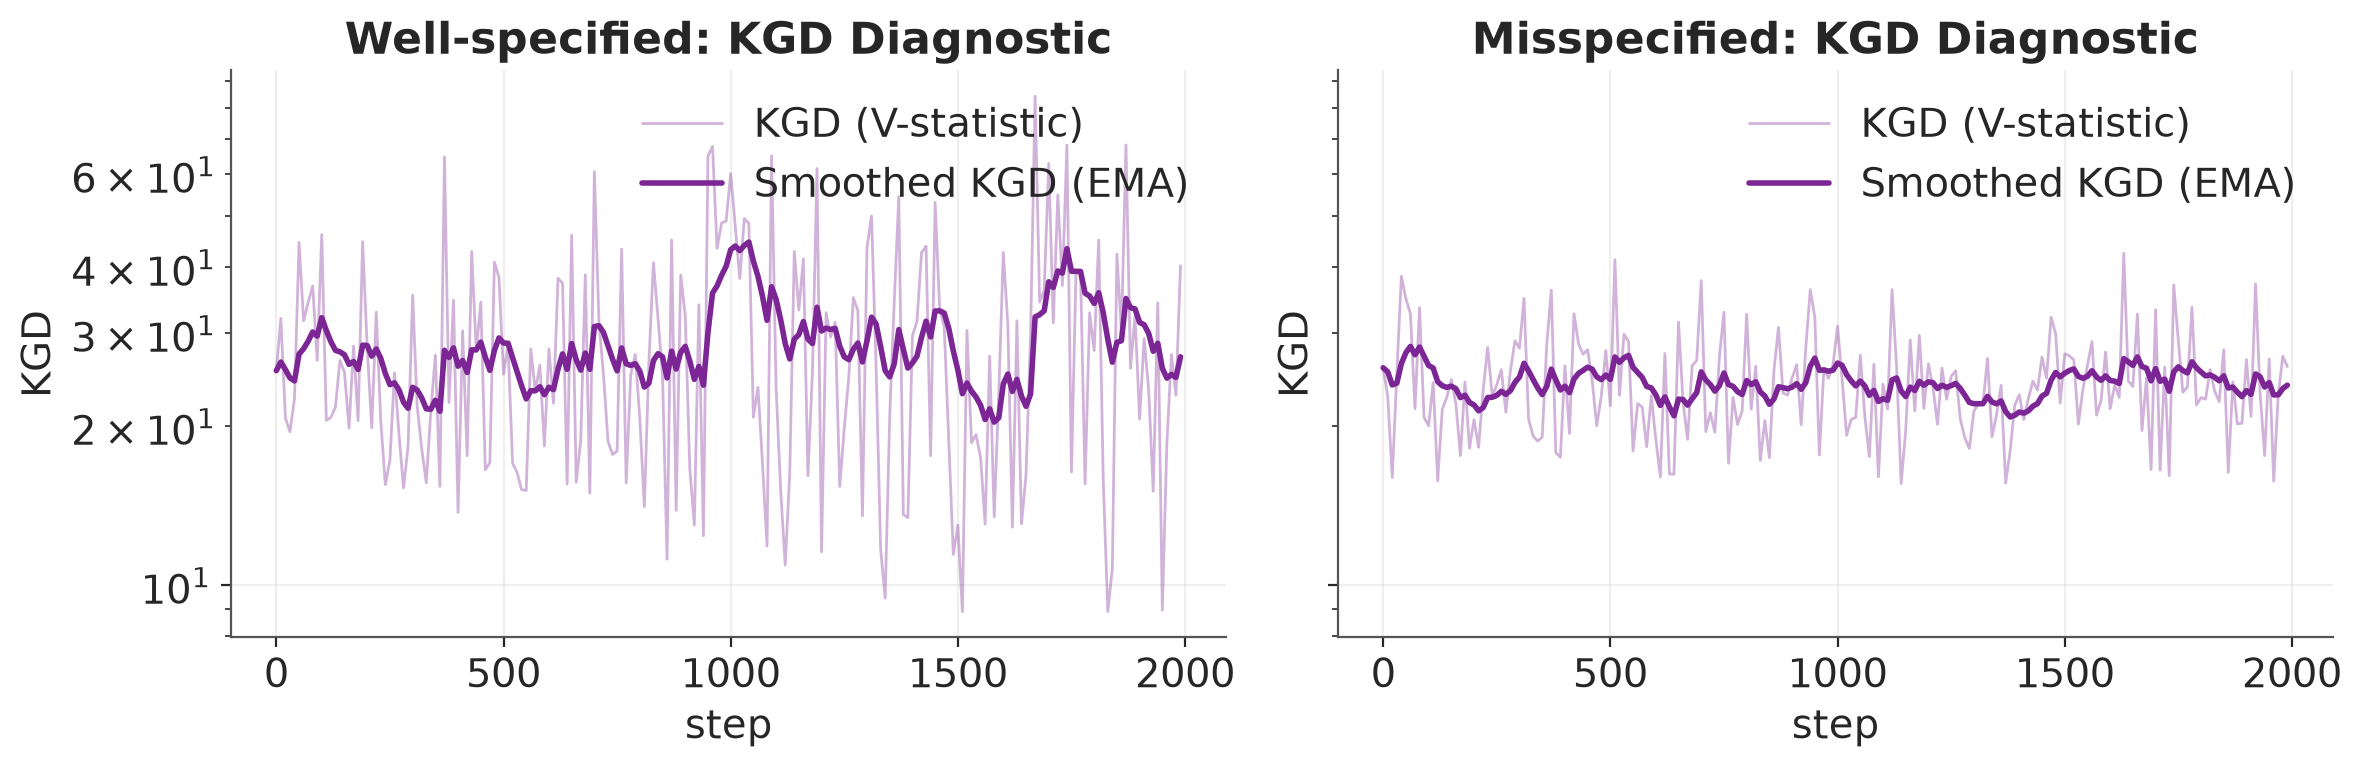

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (name, diag) in zip(axes, diagnostics.items()):
    ax.plot(diag.step, diag.kgd_raw, color="C3", alpha=0.35, lw=1.0, label="KGD (V-statistic)")
    ax.plot(diag.step, diag.kgd_ema, color="C3", lw=2.0, label="Smoothed KGD (EMA)")
    ax.set(title=f"{name.capitalize()}: KGD Diagnostic", xlabel="step", ylabel="KGD", yscale="log")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

fig.tight_layout()

## FUSE schedule diagnostics

When `step_size=None`, FUSE records per-retained-step quantities in `sample_stats`:

* **`fuse_step_size`**: Adaptive step size used that step.
* **`fuse_gradient_energy`**: Incremental gradient energy (mean squared raw drift over particles).
* **`fuse_half_step_distance_sq`**: Squared empirical distance between the fixed reference half-step and the current half-step.

These are step-only traces (identical across `chain`); we plot against simulation `step`.


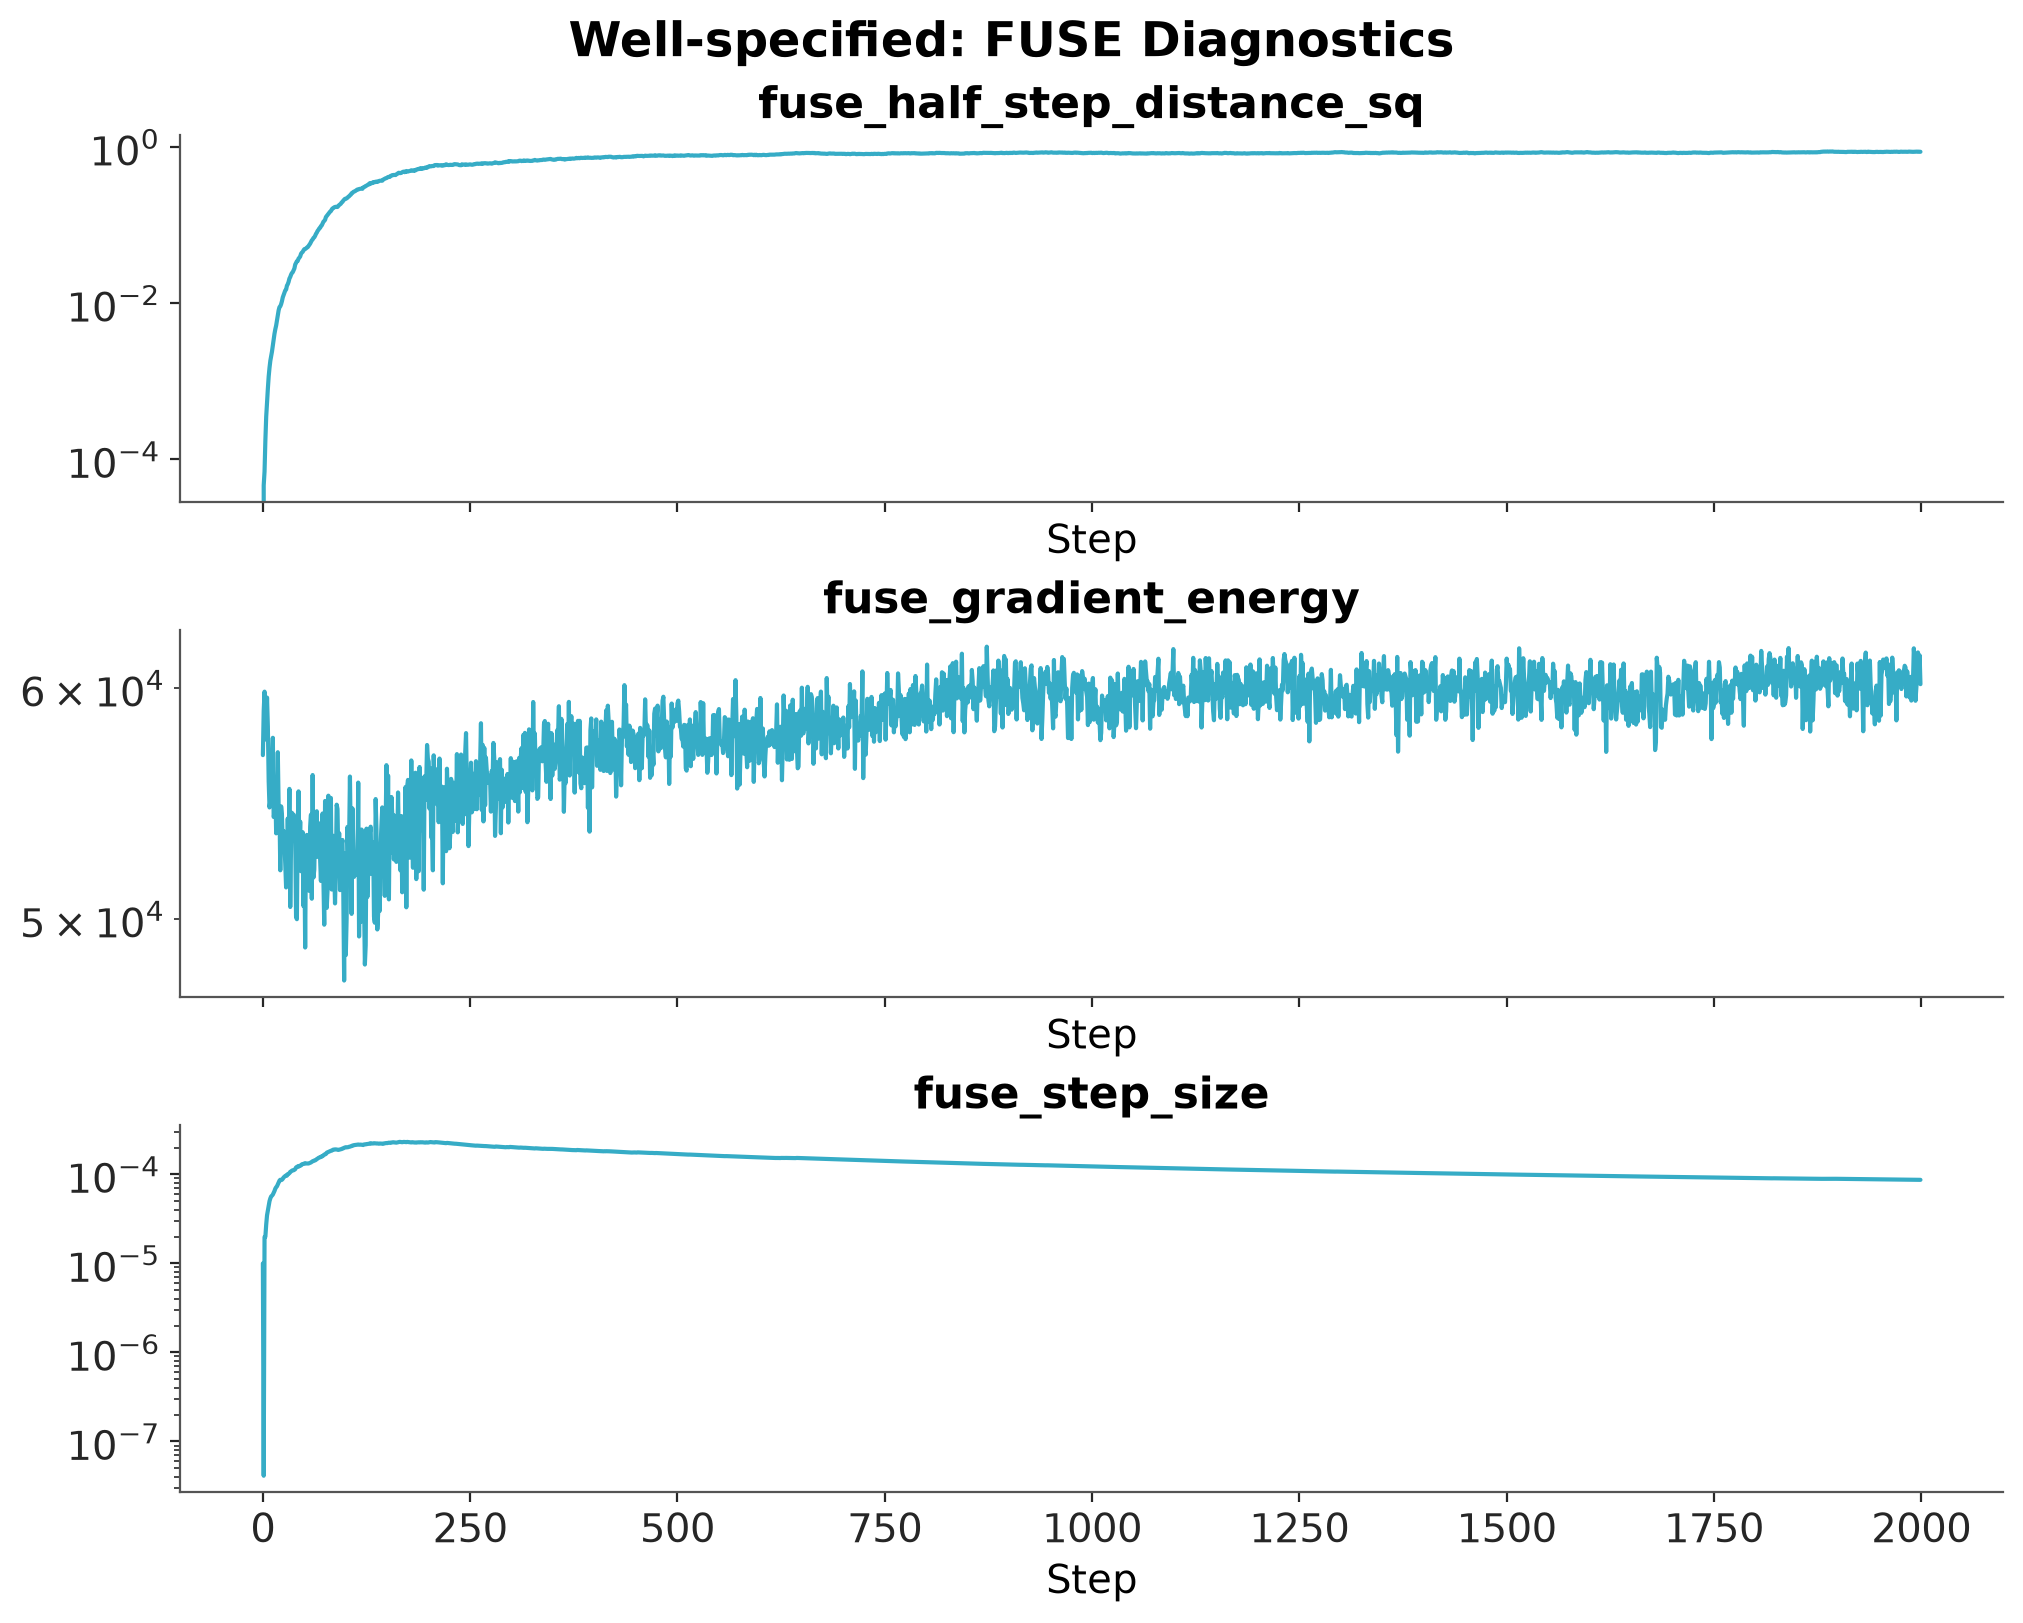

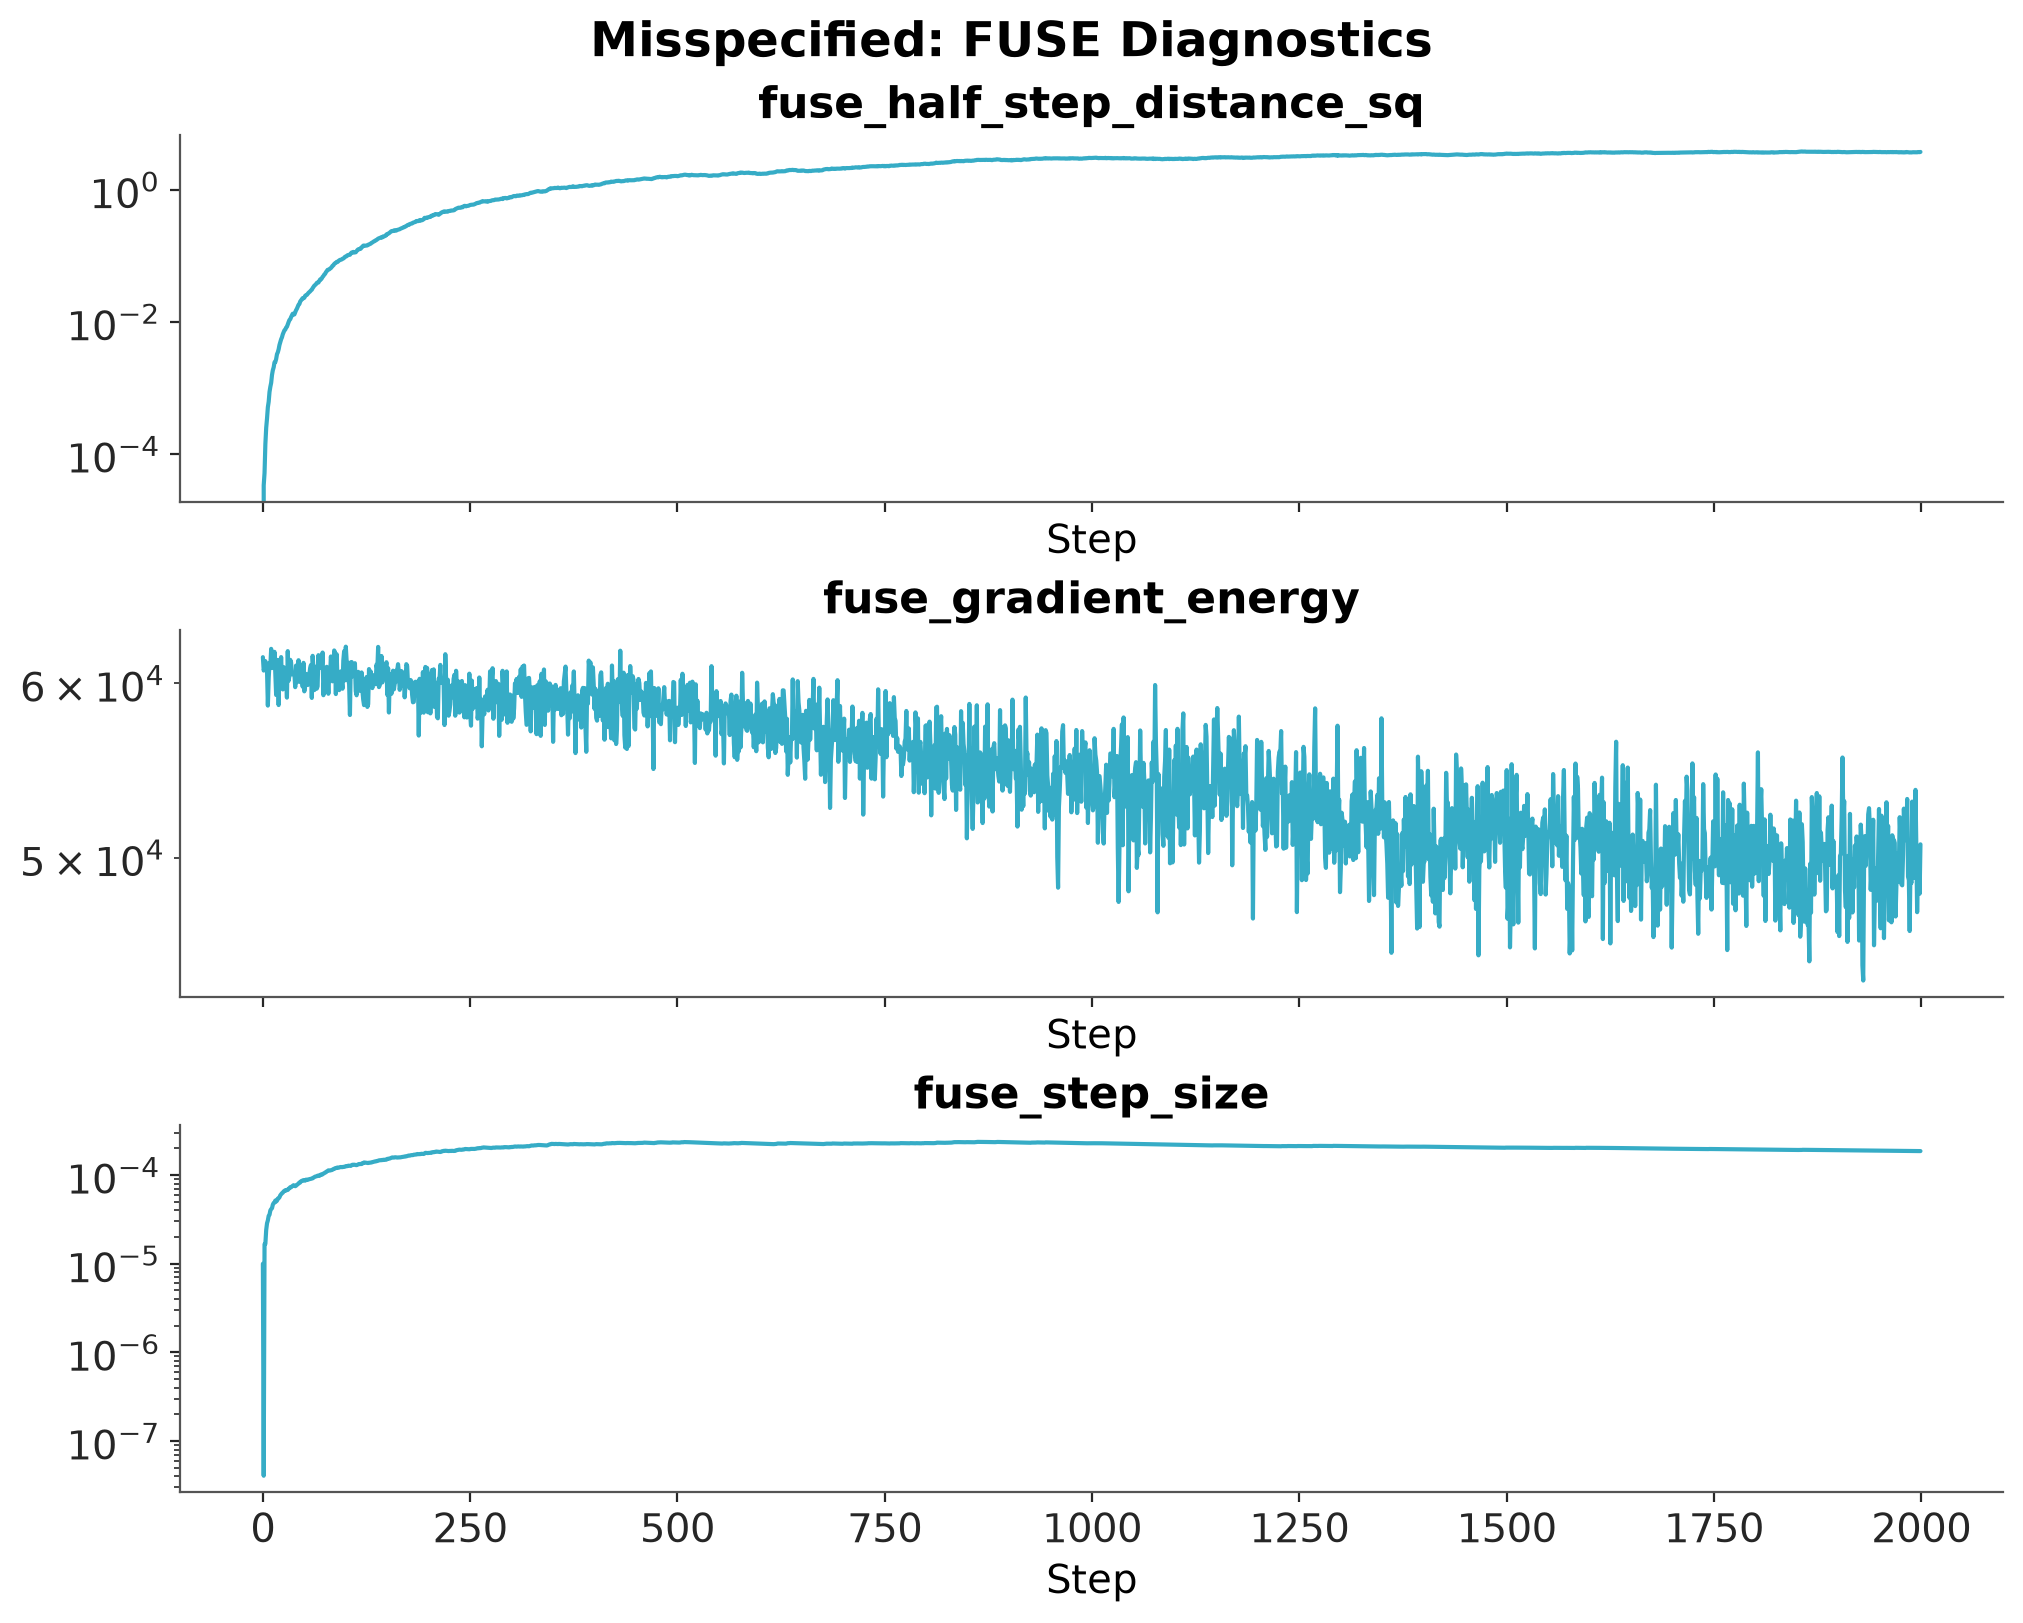

In [ ]:
diagnostic_vars = [
    "fuse_half_step_distance_sq",
    "fuse_gradient_energy",
    "fuse_step_size",
]

for name, run in pro_runs.items():
    available_vars = [v for v in diagnostic_vars if v in run.sample_stats.data_vars]
    if available_vars:
        pc = az.plot_trace(
            run.sel(chain=[0]),
            var_names=available_vars,
            group="sample_stats",
            visuals={"trace": {"xname": "step"}},
            col_wrap=1,
            figure_kwargs={"figsize": (10, 8)},
        )
        pc.facet_map("set_yscale", scale="log")
        pc.add_title(f"{name.capitalize()}: FUSE Diagnostics")
    else:
        print(f"FUSE diagnostics not present for {name} (run used fixed step_size).")

## Particle flow trajectories

We plot particle trajectories across parameter space from their initial locations sampled from the prior (open circles) to their final converged positions (dots). The black star marks the true data-generating parameter $\theta^* = (\theta_1^*, \theta_2^*)$.

* In the **well-specified** regime, the particles flow from the prior and contract tightly onto the true parameter $\theta^*$.
* In the **misspecified** regime (carrying capacity $K = 50$), no single classical parameter matches the damped dynamics. The particles naturally diversify across a predictive manifold, maintaining an optimal predictive mixture distribution $Q^*$.


/tmp/ipykernel_68163/49293682.py:24: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


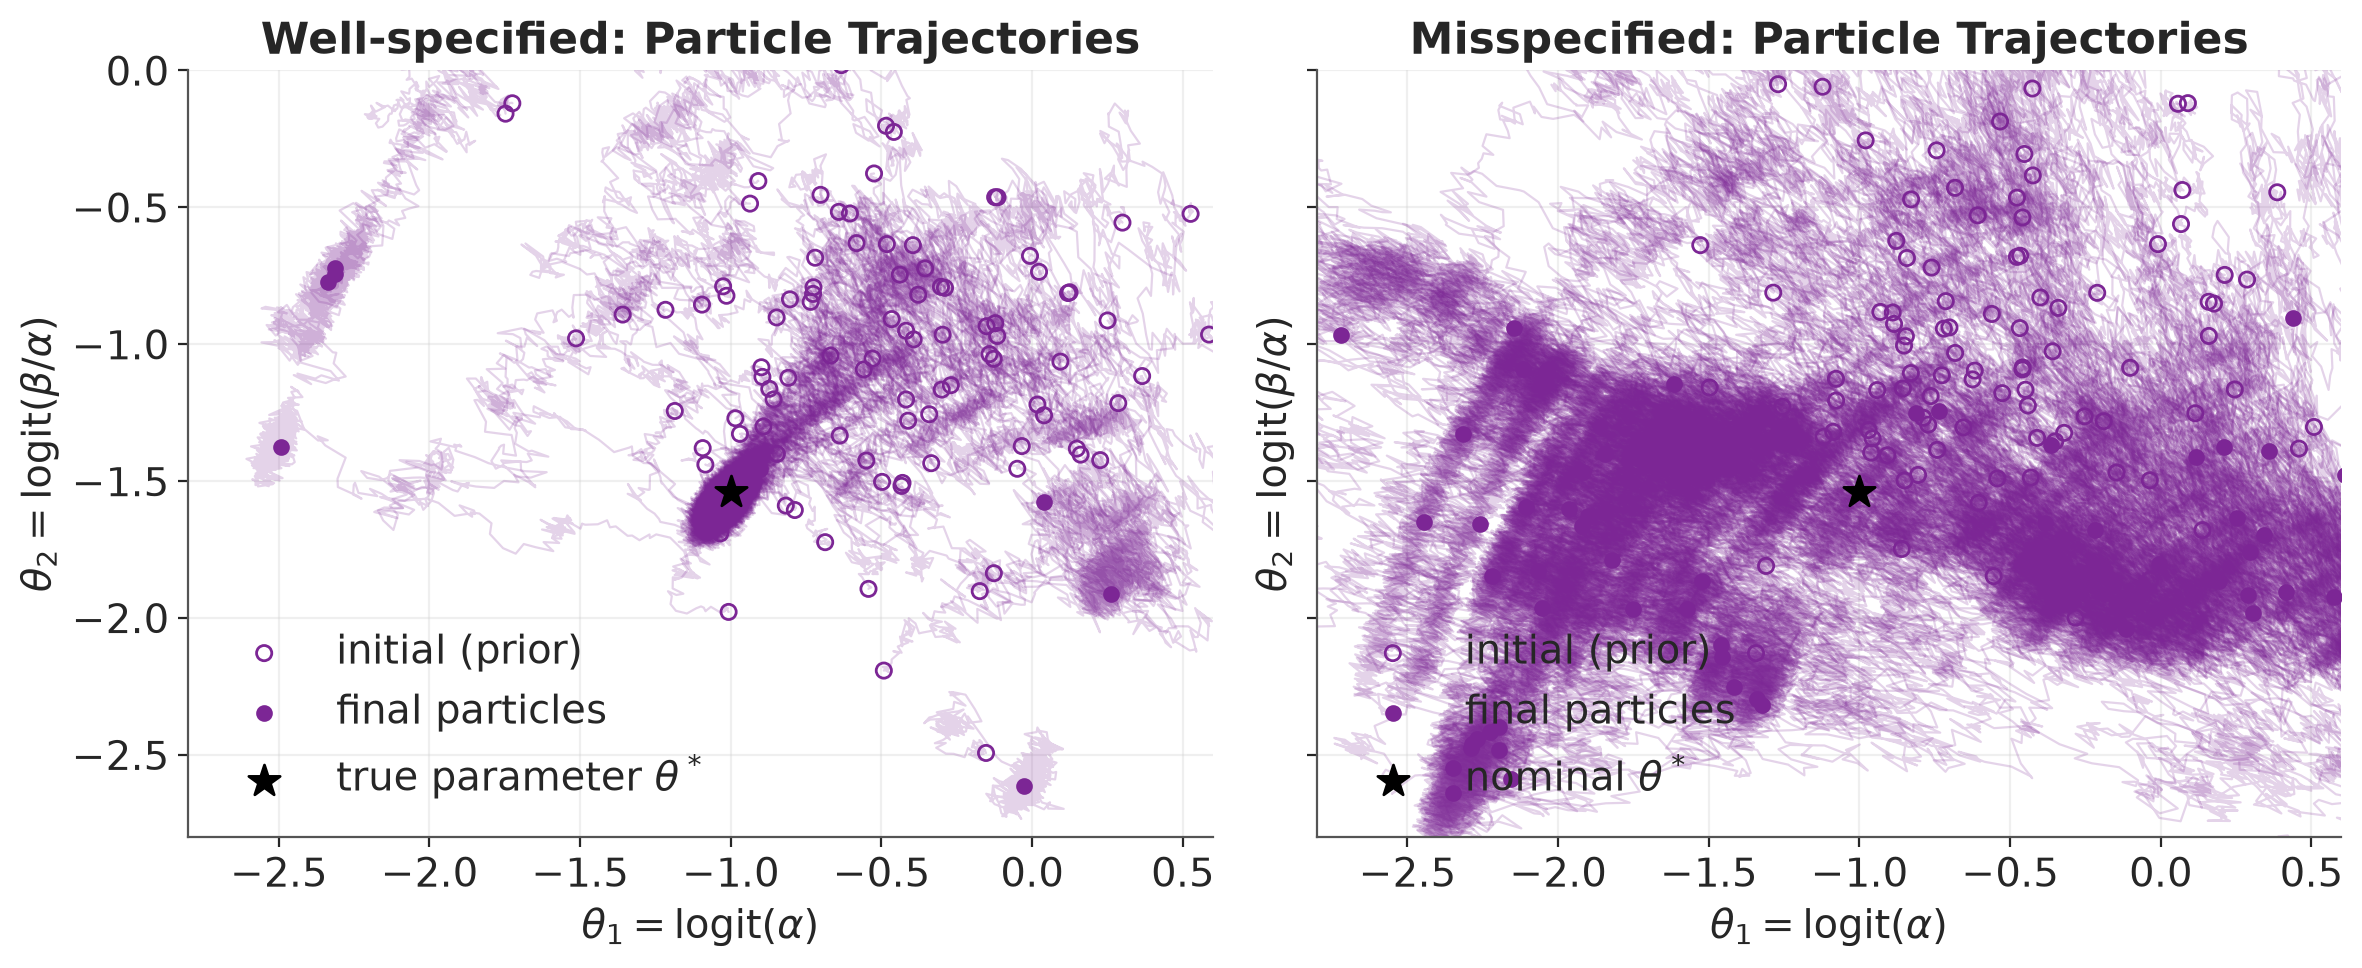

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, name in zip(axes, observed):
    particles = pro_runs[name].posterior
    initial = particles.isel(draw=0)
    final = particles.isel(draw=-1)

    for chain in particles.chain.values:
        ax.plot(
            particles.theta1.sel(chain=chain),
            particles.theta2.sel(chain=chain),
            color="C3", alpha=0.20, linewidth=0.8, zorder=1,
        )
    ax.scatter(initial.theta1, initial.theta2, facecolors="none",
               edgecolors="C3", s=30, label="initial (prior)", zorder=4)
    ax.scatter(final.theta1, final.theta2, color="C3",
               s=25, label="final particles", zorder=4)
    ax.scatter(*TRUE_THETA, marker="*", color="black", s=140,
               label=(r"true parameter $\theta^*$" if name == "well-specified" else r"nominal $\theta^*$"), zorder=5)
    ax.set(title=f"{name.capitalize()}: Particle Trajectories", xlabel=r"$\theta_1 = \operatorname{logit}(\alpha)$", ylabel=r"$\theta_2 = \operatorname{logit}(\beta / \alpha)$", xlim=(-2.8, 0.6), ylim=(-2.8, 0.0))
    ax.legend(loc="lower left", framealpha=0.9)
    ax.grid(True, alpha=0.3)

fig.tight_layout()


## Posterior predictive comparison

We compare posterior predictive draws from the converged PrO particle cloud against the Bayesian reference and the ground-truth latent trajectory. Shaded bands display the 90% predictive interval ($[0.05, 0.95]$) including observation noise, with thick solid lines showing the predictive mean.

* In the **well-specified** setting, both Bayes and PrO accurately reconstruct the true periodic cycles with matching uncertainty bands.
* In the **misspecified** setting (carrying capacity $K = 50$), the true oscillations damp over time. Bayes collapses onto a single compromise orbit, severely overpredicting later cycles and extrapolating perpetual oscillations into the future with zero epistemic uncertainty. In contrast, PrO's predictive mixture spans the changing dynamics, providing a calibrated predictive envelope that cleanly bounds the true trajectory both in-sample and out-of-sample ($t > 60$).


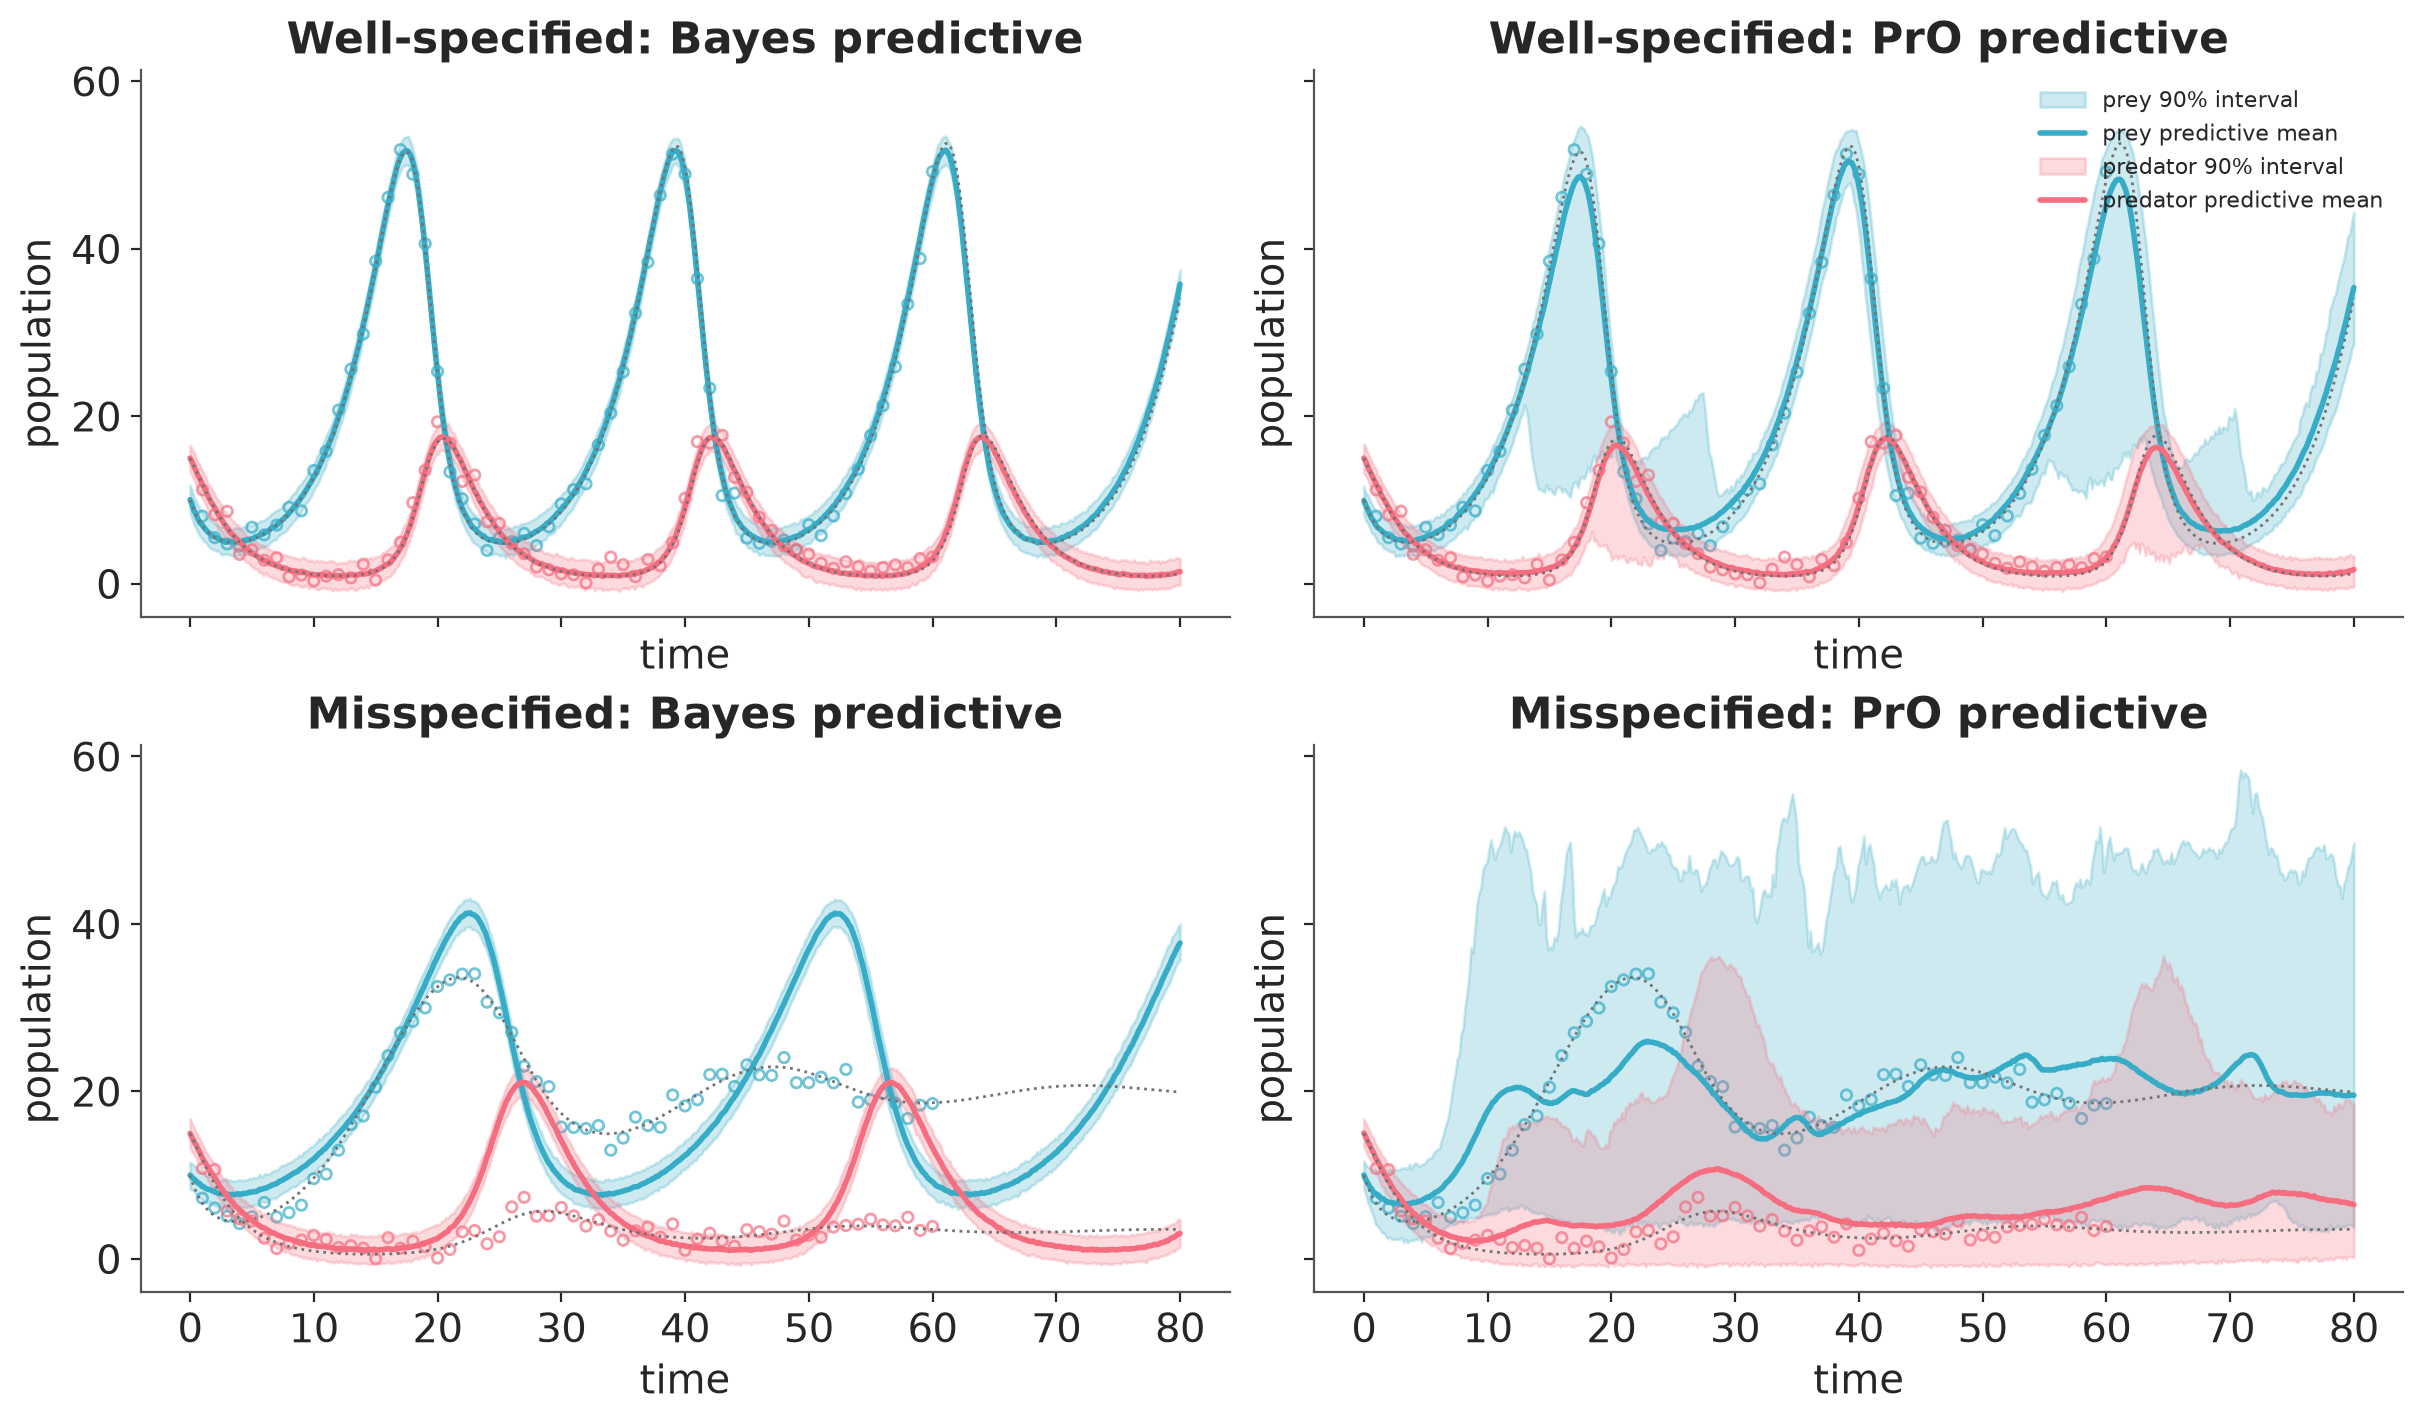

In [ ]:
def grid_reference(data, grid_size=121):
    theta1 = np.linspace(-2.5, 0.0, grid_size)
    theta2 = np.linspace(-2.5, -0.5, grid_size)
    mesh1, mesh2 = np.meshgrid(theta1, theta2, indexing='ij')
    points = np.column_stack([mesh1.ravel(), mesh2.ravel()])
    paths = simulate_deterministic(points, OBSERVATION_TIMES)
    log_prior = -0.5 * ((points[:, 0] - (-0.5)) / 0.5) ** 2 - 0.5 * ((points[:, 1] - (-1.0)) / 0.5) ** 2
    log_posterior = -0.5 * np.sum(
        ((data - paths) / OBSERVATION_SIGMA) ** 2, axis=(1, 2)
    ) + log_prior
    weights = np.exp(log_posterior - logsumexp(log_posterior))
    return theta1, theta2, points, weights

bayes = {name: grid_reference(data) for name, data in observed.items()}

N_PREDICTIVE_DRAWS = 500
predictive = {}
predictive_mean = {}

for scenario, name in enumerate(observed):
    _, _, grid, weights = bayes[name]
    rng = np.random.default_rng(SEEDS['predictive_bayes'] + scenario)
    bayes_theta = grid[rng.choice(len(grid), N_PREDICTIVE_DRAWS, p=weights)]
    bayes_paths = simulate_deterministic(bayes_theta, PREDICTION_TIMES)
    bayes_draws = bayes_paths + rng.normal(0, OBSERVATION_SIGMA, bayes_paths.shape)

    final = pro_runs[name].isel(draw=slice(-1, None), missing_dims='ignore')
    pro_theta_particles = np.column_stack([
        final.posterior.theta1.values.ravel(), final.posterior.theta2.values.ravel()
    ])
    pro_rng = np.random.default_rng(SEEDS['predictive_pro'] + scenario)
    pro_theta = pro_theta_particles[
        pro_rng.choice(len(pro_theta_particles), N_PREDICTIVE_DRAWS, replace=True)
    ]
    pro_paths = simulate_deterministic(pro_theta, PREDICTION_TIMES)
    pro_draws = pro_paths + pro_rng.normal(0, OBSERVATION_SIGMA, pro_paths.shape)

    predictive[name] = {'Bayes': bayes_draws, 'PrO': pro_draws}
    predictive_mean[name] = {
        'Bayes': bayes_draws.mean(axis=0),
        'PrO': pro_draws.mean(axis=0),
    }

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True, layout='constrained')
colors = ['C0', 'C1']
labels = ['prey', 'predator']

for row, name in enumerate(observed):
    for col, method in enumerate(['Bayes', 'PrO']):
        ax = axes[row, col]
        for species in range(2):
            draws = predictive[name][method][:, :, species]
            mean = predictive_mean[name][method][:, species]
            lower, upper = np.quantile(draws, [0.05, 0.95], axis=0)
            ax.fill_between(PREDICTION_TIMES, lower, upper, color=colors[species], alpha=0.25, label=f'{labels[species]} 90% interval')
            ax.plot(PREDICTION_TIMES, mean, color=colors[species], lw=2.0, label=f'{labels[species]} predictive mean')
            ax.plot(latent_times[name], latent[name][:, species], color='0.45', lw=1.0, ls=':')
            ax.scatter(OBSERVATION_TIMES, observed[name][:, species],
                       facecolors='none', edgecolors=colors[species], s=14, alpha=0.7)
        ax.set(title=f'{name.capitalize()}: {method} predictive', xlabel='time', ylabel='population')
axes[0, 1].legend(loc='upper right', fontsize=8)
